# $\Psi(2S)$ discovery with CMS data
#### Gabriele Radano, Matteo Bellino - Spring semester 2025

# 0. Importing packages

In [48]:
# Importing packages
import pickle as pkl                 # Needed to import the pkl files
import numpy  as np
import matplotlib.pyplot as plt
import lmfit                         # Package to minimize functions (it is more well-structured than scipy.optimize)
from dataclasses import dataclass
from scipy.integrate import quad     # Numerical integral evaluation, useful to compute the integral of the model inside the bin
import sys                           # Needed to know what's the highest float value accepted
from collections.abc import Iterable # Needed to check inside crystall_ball if we are giving an array or a float

# 1. Loading data

In [9]:
# Importing data from files
with open('DataSet.pkl', 'rb') as file: # The 'rb' stands for 'read binary', necessary for this kind of file
    data_HS = pkl.load(file)            # Data with High Statistics 
    
with open('DataSet_lowstat.pkl', 'rb') as file:
    data_LS = pkl.load(file)            # Data with Low Statistics

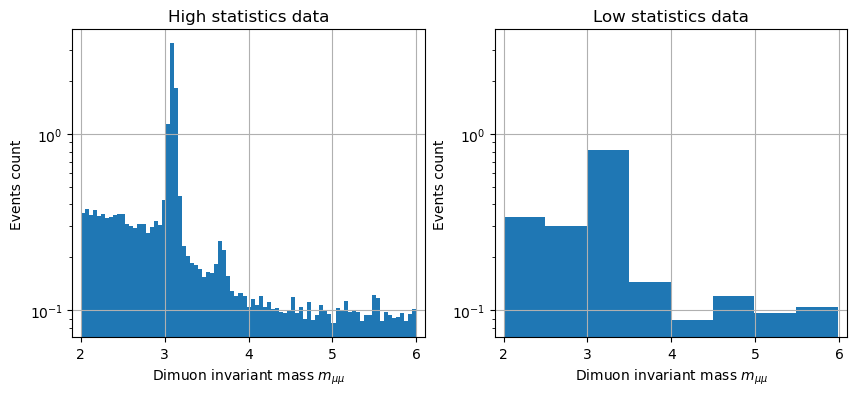

In [10]:
# Plotting raw data
normalize = True
scale     = 'log'
bin_num   = int(np.sqrt(len(data_HS))/2)

fig, axes = plt.subplots(1,2, figsize=(10,4))

ax = axes[0]
ax.grid(1)
ax.hist(data_HS, density=normalize, bins=bin_num)
ax.set_title('High statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_yscale(scale)
ylim = ax.set_ylim()

ax = axes[1]
ax.grid(1)
ax.hist(data_LS, density=normalize, bins=int(bin_num/10))
ax.set_title('Low statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_ylim(ylim)
ax.set_yscale(scale)
plt.show()

# 2. Defining the model

## 2.1. Bare background

We want to use chebyshev polynomials to model the bare bkg, excluding the resonance of the J/$\Psi$ and the signal we are looking for of the $\Psi$(2S) we need to perform the following operations:
1. Make the polynomials positive:
   add 1 to each element of the polynomial
2. Normalize the polynomial in $[-1,1]$ (can be done analytically)
3. Take a linear combination and normalize the sum in $[-1,1]$ (one could simply normalize at the end)  

At this point one gets the following result:
\begin{equation}
    f(x) = \{a_3 \cdot \frac{(4x^3-3x +1)}{2} + a_2\cdot\frac{3x^2}{2} + a_1\cdot \frac{x+1}{2} + a_0\frac{1}{2}\} / {\sum a_i}
\end{equation}
However, we want to describe a pdf in the interval $[2,6]$, therefore we must perform a change of variable. Given z in $[2,6]$:
\begin{equation}
    x = -1 + 2 \frac{z-2}{6-2} \in [-1,1]
\end{equation}

**Watch out!**
Since probability/normalization must be conserved and we changed the measure, the pdf obtained applying the change of vairable must be divided by $dx/dz = 2$.

In [11]:
# Chebyshev polynomials model

# There are also some functions that compute the polynomials: numpy.chebychev and numpy.chebyshev.b...(something)
def cheb3r(z, params): 
    '''Rescaled cheb polynomial of order 3
    
    Here each polynomial has been normalized and translated by 1 before taking the linear combination. 
    This function also maps the value of the cheb polynomials from -1 to 1 (where they form an orthogonal set) 
    to the interval of interest [2,6]'''
    a0, a1, a2, a3 = params
    x = -1 + 2*(z-2) / (6-2) # I'm making a change of var so then I'll have to divide the final linear combination by dx/dz = 2
    norm =  a0 + a1 + a2 + a3 # Normalization IN THE INTERVAL [-1,1] (space of coorddinates X)
    linear_combination = (a3*(4*x**3-3*x +1)/2 + a2*3/2*x**2 + a1*(x+1)/2 + a0/2) / norm / 2 # the additional factor 2 accounts for change of coord (to preserve probability)
    
    return np.array(linear_combination)

## 2.2. J/$\Psi$ and $\Psi(2S)$ resonances

We model the peak of the J/$\Psi$ resonance with a crystal ball distribution, which is conceived to describe the invariant mass distribution in the presence of energy losses (brehmstralung radiation). In our case, we are interested at a one-sided crystall ball, with the polynomial tail to the left (lower invariant masses due to energy loss). The distribution is a piecewise function, which turns to a polynomial at a certain point:
\begin{equation}
    f(x) = N\cdot\begin{cases}
    e^{-\frac{(x-\mu)^2}{2\sigma^2}} \qquad\qquad\qquad \frac{x-\mu}{\sigma}>-\alpha\\
    A\cdot(B-\frac{x-\mu}{\sigma})^{-n} \qquad \frac{x-\mu}{\sigma}<-\alpha
    \end{cases}
\end{equation}
The parameters $A, B$ are known, the factor N ensures proper normalization.

In [12]:
# Crystal-ball model

def gaussian(x, params):
    '''Un-normalized gaussian

    This function evaluates the value of an un-normalized gaussian having parameters mu,sigma=params.
    The normalization is avoided because it is performed inside the crystall_ball function, after ad-
    dint the polynomial tail to one side of the gaussian.'''
    mu, sigma = params
    return np.array(np.exp(- (x-mu)**2/(2*sigma**2)))

def poly_tail(x, params):
    '''Left polynomial tail of a crystall ball distribution

    The function requires the parameters mu,sigma,alpha,n which are the mean and std deviation of the 
    gaussian bulk, the switch point between gaussian and polynomial and the order of the polynomial,
    respectively.'''
    mu, sigma, alpha, n = params
    A = (n/np.abs(alpha))**n * np.exp(-np.abs(alpha)**2/2)
    B = n/np.abs(alpha) - np.abs(alpha)
    return np.array(A * (B - (x-mu)/sigma)**(-n))

def crystal_ball(x, params):
    '''Normalized crystall ball pdf
    
    Function that returns the value of a crystal ball distribution normalized in the range [2,6]. It
    needs the parameters [mu, sigma, alpha, n] which are the mean and std deviation of the  gaussian
    bulk, the switch point between gaussian and polynomial and the order of the polynomial, respe-
    ctively.'''
    if isinstance(x, Iterable):
        pass
    else:
        x = [x]
    mu, sigma, alpha, n = params

    turning_point = mu - alpha*sigma
    int_tail, _   = quad(lambda y: poly_tail(y, params),     2            , turning_point)
    int_gauss, _  = quad(lambda y: gaussian (y, [mu,sigma]), turning_point, 6            )
    normalization = 1/(int_tail+int_gauss)

    pdf = []
    for point in x:  
        if   (point-mu)/sigma >  -alpha:
            pdf.append( gaussian(point, [mu,sigma])*normalization )
        elif (point-mu)/sigma <= -alpha:
            pdf.append( poly_tail(point, params)   *normalization )
    return np.array(pdf)

## 2.3. Combined model

Combining the three features we observe in the invariant mass spectrum may result in a big mess if not handled properly. Here we describe how we intend to tackle the problem. First, a rescaled-pdf will be defined *combined_model*: it will be obtained as

$$combined\_model(x) = \text{N}_\text{bkg}\cdot cheb3r(x) + \text{N}_\text{JPsi}\cdot crystal\_ball(x) + \text{N}_\text{Psi2S}\cdot crystal\_ball(x)$$

where each pdf is multiplied by the corresponding yield (the number of events expected for bkg, JPsi and Psi2S). Since each constituting pdf is normalized, the integral of this combined model is the total number of expected events. Keep in mind that the yield of the Psi2S resonance is expressed in terms of the cross section of the process as follows

$$\text{N}_{Psi2S} = 0.75 \cdot 37 \cdot \text{cross\_section}$$

where the efficiency (0.75) and the luminosity (37 inverse pb) are fixed and the cross section is expressed in pb. The other yields are simple optimization parameters.

This function is ready to be integrated inside each bin to provide the number of events the model predicts inside that bin. This integration will be performed by another function that will simply integrate combined_model inside the bins.

In [24]:
# Unpacking the parameters

def params_unpacker(params):
    '''This function unpacks the parameters of the combined model

    Given the great amount of parameters we have, using the lmfit package is a more clear and understandable
    option instead of scipy.optimize which simply relies on the ordering of the parameters. The drawback is
    that the parameters are now <class 'lmfit.parameter.Parameters'>. 
    This function is meant to unpack the new values of the parameters and distribute them among the various
    pdfs that are summed to produce the combined model.
    It returns a dictionary with keys bkg, JPsi, Psi2S and combined_model with the arrays of parameters of
    the corresponding pdfs, already ordered as the functions require.'''
    params_bkg            = np.zeros(4) # a0, a1, a2, a3                     - coefficients of the linear combination of Chebyshev polynomials
    params_JPsi           = np.zeros(4) # mu, sigma, alpha, n                - parameters of the Crystal ball of the J/Psi resonance
    params_Psi2S          = np.zeros(4) # mu, sigma, alpha, n                - parameters of the Crystal ball of the Psi(2S) resonance
    params_combined_model = np.zeros(3) # N_bkg, N_JPsi, cross_section_Psi2S - yields and cross section of the three components of the spectrum

    for key in params:
        if   key=='a0': params_bkg[0] = params[key].value
        elif key=='a1': params_bkg[1] = params[key].value
        elif key=='a2': params_bkg[2] = params[key].value
        elif key=='a3': params_bkg[3] = params[key].value

        elif key=='mu_JPsi':    params_JPsi[0] = params[key].value
        elif key=='sigma_JPsi': params_JPsi[1] = params[key].value
        elif key=='alpha_JPsi': params_JPsi[2] = params[key].value
        elif key=='n_JPsi':     params_JPsi[3] = params[key].value

        elif key=='mu_Psi2S':    params_Psi2S[0] = params[key].value
        elif key=='sigma_Psi2S': params_Psi2S[1] = params[key].value
        elif key=='alpha_Psi2S': params_Psi2S[2] = params[key].value
        elif key=='n_Psi2S':     params_Psi2S[3] = params[key].value

        elif key=='N_bkg':               params_combined_model[0] = params[key].value
        elif key=='N_JPsi':              params_combined_model[1] = params[key].value
        elif key=='cross_section_Psi2S': params_combined_model[2] = params[key].value

        else:
            raise KeyError('Unrecognized parameter')

    param_dict = {'bkg':            params_bkg,
                  'JPsi':           params_JPsi,
                  'Psi2S':          params_Psi2S,
                  'combined_model': params_combined_model,
                 }

    return param_dict

In [28]:
# Combined model

def combined_model(x,params):
    '''Overall model describing the invariant mass distribution

    This function factors in all the features we observe in the invariant mass distribution: the background,
    the J/Psi resonance and the Psi(2S) resonance. Unfortunately, since they have to be combined after mul-
    tiplying each pdf by the corresponding yield (how many events we expect to observe coming from bkg, JPsi
    or Psi2S respectively), this is not a pdf anymore but a rescaled one: its integral is the total number
    of expected events (the sum of the yields of bkg, JPsi, Psi2S).
    The provided parameters must include all the parameters needed by the underlying pdfs (one cheby3r, two 
    crystal_ball) and the parameters needed to combine them: N_bkg, N_JPsi and cross_section_Psi2S.'''

    # Distributing the parameters
    params_dict = params_unpacker(params)
    params_bkg            = params_dict['bkg']
    params_JPsi           = params_dict['JPsi']
    params_Psi2S          = params_dict['Psi2S']
    params_combined_model = params_dict['combined_model']

    # Unpacking the parameters needed to combine the pdfs
    N_bkg, N_JPsi, cross_section_Psi2S = params_combined_model
    N_Psi2S = 0.75 * 37 * cross_section_Psi2S

    model = N_bkg   * cheb3r      (x, params_bkg)  +\
            N_JPsi  * crystal_ball(x, params_JPsi) +\
            N_Psi2S * crystal_ball(x, params_Psi2S)

    return model

# 3. Fitting

In [39]:
# Defining the initial parameters

initial_params = lmfit.create_params(
    N_bkg               = {'value': 5000,  'min': 0,      'max': 50000, 'vary': True},
    a0                  = {'value': 0,     'min': -2,     'max': 2,     'vary': True},
    a1                  = {'value': -0.7,  'min': -2,     'max': 2,     'vary': True},
    a2                  = {'value': 0.3,   'min': -2,     'max': 2,     'vary': True},
    a3                  = {'value': -0.03, 'min': -2,     'max': 2,     'vary': True},

    N_JPsi              = {'value': 1500,  'min': 0,      'max': 10000, 'vary': True},
    mu_JPsi             = {'value': 3.1,   'min': 2.8,    'max': 3.4,   'vary': True},
    sigma_JPsi          = {'value': 0.3,   'min': 0.0001, 'max': 1,     'vary': True},
    alpha_JPsi          = {'value': 1.5,   'min': -5,     'max': 5,     'vary': True},
    n_JPsi              = {'value': 1.5,   'min': 0.5,    'max': 10,    'vary': True},

    cross_section_Psi2S = {'value': 3,     'min': 0,      'max': 40,    'vary': True},
    mu_Psi2S            = {'value': 3.7,   'min': 2.5,    'max': 3.95,  'vary': True},
    sigma_Psi2S         = {'value': 0.3,   'min': 0.0001, 'max': 1,     'vary': True},
    alpha_Psi2S         = {'value': 1.5,   'min': -5,     'max': 5,     'vary': True},
    n_Psi2S             = {'value': 1.5,   'min': 0.5,    'max': 10,    'vary': True},    
)

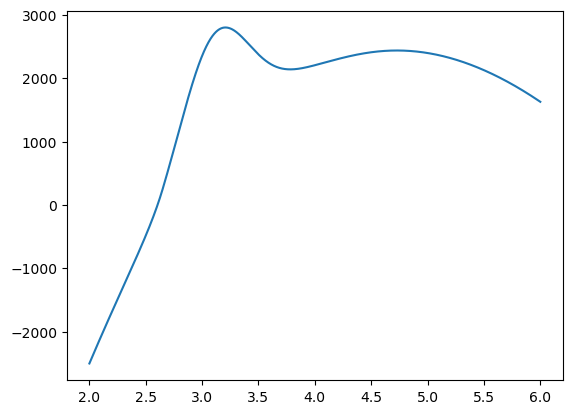

In [47]:
# Plotting just for fun

x = np.linspace(2,6, 10000)
y = combined_model(x, initial_params)

plt.plot(x,y)
plt.show()

In [2]:
def get_binned_model(model, params, bin_edges):
    '''Numerical integral of the model

    This function returns the integral of the given model, integrated inside each bin, so that it can be
    compared with the binned data. IMPORTANT: It requires the parameters of the model which MUST be normalized be-
    tween 2 and 6; the n+1 edges of the n bins used to bin the data. It returns an array with n entries
    (one per bin) containing the integral of the model evaluated in that bin.'''
    
    integrand = lambda x: model(x, params)
    Nbins = len(bin_edges)-1
    binned_model = [0] * Nbins 
    
    for i in range(0, Nbins):
        lower_extreme = bin_edges[i]
        upper_extreme = bin_edges[i+1]
        binned_model[i], _ = quad(integrand, lower_extreme, upper_extreme)
    
    binned_model = np.array(binned_model)
    #print(np.sum(binned_model))
    return binned_model
    

In [129]:
@dataclass
class get_bNLL(): # Function to evaluate the binned Negative Log Likelihood
    data:       np.array
    bin_number: int
    model:      callable # Not the model but a function that evaluates its integral inside each bin. It
                         # the model parameters and the edges of the bin (n+1 edges for n bins)

    def __post_init__(self):
        self.binned_data, self.bin_edges = np.histogram(self.data, bins=self.bin_number, density=False)

    def __call__(self, params):
        '''Evaluates the binned Negative Log Likelihood

        This function only requires the parameters of the model being used
        It is the callable function of the class get_bNLL which already has the binned data, the bin edges 
        and the model we are comparing the data to.
        We assume that the number of points inside each bin follows a Poisson distribution: the parameter
        lambda (the expectation value of events inside each bin) is the model's integral over the same bin.'''

        N_model = len(self.data) # THIS IS JUST FOR TESTING <---------------------------------------------------------------------------
        binned_model = get_binned_model(self.model, params, self.bin_edges) * N_model #multiplied by the number of data since the output of get-binned_model is normalized

        x = np.linspace(2,6, 10000) # To ensure we don't consider models with negative values <-----------------------------------------
        if any(self.model(x,params)<0):
            bNLL = sys.float_info.max # This is the highest possible float supported by the computer
        else:
            bNLL = sum( binned_model - self.binned_data*np.log(binned_model) )

        return bNLL    

[ 1.15026107 -0.59795992  0.18493821 -0.06548733]


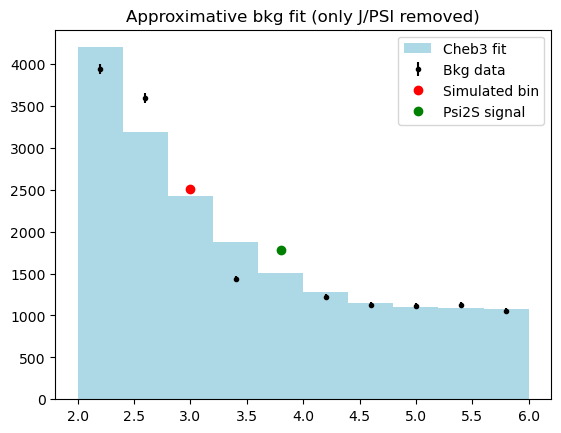

In [130]:
#cheb3 fit
Nbins = 10

fake_dataset = np.array([3]*2512) #We made up this dataset in order to simulate (approximately) the background in the removed part
                                  #We chose to make the bin 2512 high because it is the mean between the two surrounding bin counts (2512)

data_simil_bkg = np.concatenate((data_HS[(data_HS<2.8) | (data_HS>3.3)], fake_dataset ))

bNLL_HS_cheb3r = get_bNLL(data=data_simil_bkg,
                         bin_number=Nbins,
                         model=cheb3r)
initial_params = [1.15, -0.6, 0.18, -0.065] #given by the project instructions

optimization_results = minimize(bNLL_HS_cheb3r, initial_params,  method='L-BFGS-B')
optimized_params = optimization_results.x
print(optimized_params)
x = np.linspace(2,6,1000)

data_counts, bin_edges = np.histogram(data_simil_bkg, bins=Nbins, density = False)
err_data_counts = np.sqrt(data_counts)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
bin_widths = np.diff(bin_edges)

binned_result = get_binned_model(cheb3r, optimized_params, bin_edges) * len(data_simil_bkg)

plt.bar(bin_edges[:-1], binned_result, width=np.diff(bin_edges), align='edge', color = 'lightblue', label="Cheb3 fit")#, edgecolor = "black")
plt.errorbar(bin_centers, data_counts, yerr = err_data_counts, fmt = ".", linestyle = "None", color='black', label='Bkg data')
plt.errorbar(bin_centers[2], data_counts[2], fmt = "o", color = "red", label = "Simulated bin")
plt.errorbar(bin_centers[4], data_counts[4], fmt = "o", color = "green", label = "Psi2S signal")
plt.title("Approximative bkg fit (only J/PSI removed)")
plt.legend()
plt.show()

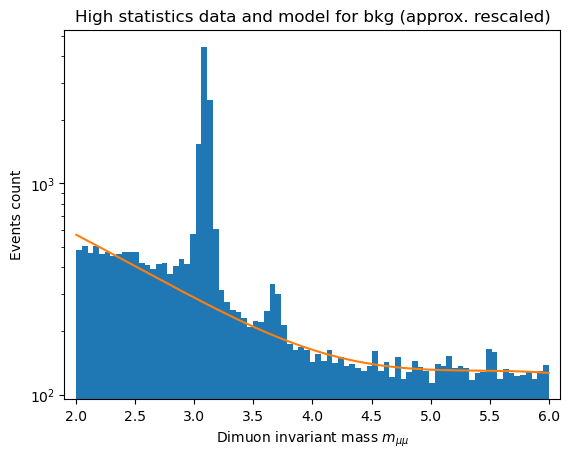

In [131]:
x = np.linspace(2,6, 1000)
y = cheb3r(x, optimized_params)
#plt.plot(x,y)
plt.figure()
plt.yscale('log')
plt.hist(data_HS, density=False, bins=bin_num)
plt.title('High statistics data and model for bkg (approx. rescaled)')
plt.xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
plt.ylabel('Events count')
plt.xlim((1.9,6.1))
ylim = plt.ylim()
plt.plot(x,y*900)

(1.9, 6.1)

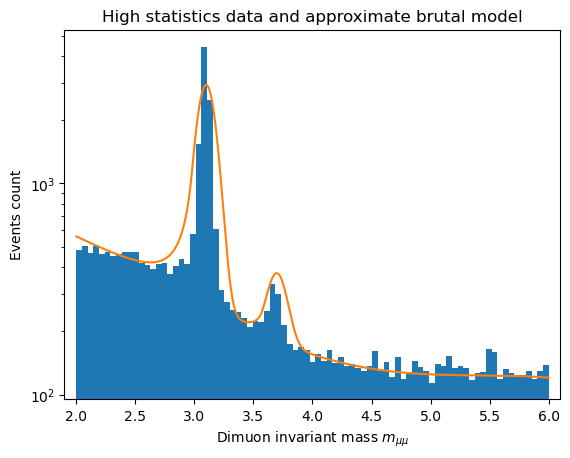

In [132]:
#Plot of the functions brutally superpositioned
x = np.linspace(2, 6, 1000)
f_JPSI = 0.4
f_PSI2s = 0.03
f_bkg = 1 - f_JPSI - f_PSI2s

bkg = cheb3r(x, optimized_params)
JPSI = crystal_ball(x, [3.1, 0.08, 1.5, 1.5]) #[3.1, 0.3, 1.5, 1.5] are the values reported in the sheet
PSI2s = crystal_ball(x, [3.7, 0.08, 1.5, 1.5]) #[3.7, 0.3, 1.5, 1.5] are the values reported in the sheet

plt.figure()
plt.hist(data_HS, density=False, bins=bin_num)
total = f_JPSI*JPSI + f_PSI2s * PSI2s + f_bkg * bkg
plt.yscale("log")
plt.plot(x,total*1500)
plt.title('High statistics data and approximate brutal model')
plt.xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
plt.ylabel('Events count')
plt.xlim((1.9,6.1))

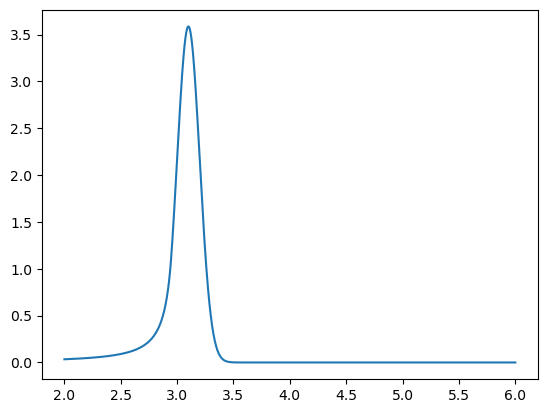

In [133]:
#just a plot of the crystal ball
x = np.linspace(2, 6, 1000)
JPSI = crystal_ball(x, [3.1, 0.1, 1.5, 1.5])
plt.figure()
plt.plot(x,JPSI)